## **1. Objective**

To implement and compare RNN, LSTM, and GRU models for sentiment classification using a sentiment-analysis dataset.


## **2. Dataset**

We will use the IMDB Movie Reviews dataset.

It contains movie reviews classified into two sentiment classes:
- 0 → Negative

- 1 → Positive

The dataset is convenient because TensorFlow/Keras can load it directly.

## **Import Libraries**

In [1]:
import tensorflow as tf
import numpy as np
import pandas as pd
import time

from tensorflow.keras.datasets import imdb
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, LSTM, GRU, Dense

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

## **2. Load IMDB Dataset**


In [2]:
# Number of words to keep
vocab_size = 10000

# Load dataset
(x_train, y_train), (x_test, y_test) = imdb.load_data(num_words=vocab_size)

print("Training samples:", len(x_train))
print("Testing samples:", len(x_test))

17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Training samples: 25000
Testing samples: 25000


## **3. Padding**


In [3]:
max_length = 200

x_train = pad_sequences(
    x_train,
    maxlen=max_length,
    padding='post',
    truncating='post'
)

x_test = pad_sequences(
    x_test,
    maxlen=max_length,
    padding='post',
    truncating='post'
)

print("Training shape:", x_train.shape)
print("Testing shape:", x_test.shape)

Training shape: (25000, 200)
Testing shape: (25000, 200)


## **4. Create RNN Model**

In [4]:
def create_rnn_model():
    model = Sequential([
        Embedding(vocab_size, 128, input_length=max_length),
        SimpleRNN(64),
        Dense(1, activation='sigmoid')
    ])

    model.compile(
        optimizer='adam',
        loss='binary_crossentropy',
        metrics=['accuracy']
    )

    return model

## **5. Train RNN**


In [5]:
rnn_model = create_rnn_model()

start_time = time.time()

rnn_model.fit(
    x_train,
    y_train,
    epochs=5,
    batch_size=128,
    validation_split=0.2,
    verbose=1
)

rnn_time = time.time() - start_time

print("RNN Training Time:", rnn_time, "seconds")

Epoch 1/5


/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


157/157 ━━━━━━━━━━━━━━━━━━━━ 25s 146ms/step - accuracy: 0.4993 - loss: 0.6944 - val_accuracy: 0.5038 - val_loss: 0.6936
Epoch 2/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 28s 176ms/step - accuracy: 0.6209 - loss: 0.6260 - val_accuracy: 0.5142 - val_loss: 0.7299
Epoch 3/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 19s 123ms/step - accuracy: 0.7272 - loss: 0.4368 - val_accuracy: 0.5054 - val_loss: 0.8690
Epoch 4/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 21s 124ms/step - accuracy: 0.7548 - loss: 0.3747 - val_accuracy: 0.5004 - val_loss: 0.9728
Epoch 5/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 21s 131ms/step - accuracy: 0.7760 - loss: 0.3480 - val_accuracy: 0.5060 - val_loss: 1.0277
RNN Training Time: 113.99102401733398 seconds


## **6. Evaluate RNN**

In [6]:
rnn_predictions = rnn_model.predict(x_test)

rnn_predictions = (rnn_predictions > 0.5).astype(int).flatten()

rnn_accuracy = accuracy_score(y_test, rnn_predictions)
rnn_precision = precision_score(y_test, rnn_predictions)
rnn_recall = recall_score(y_test, rnn_predictions)
rnn_f1 = f1_score(y_test, rnn_predictions)

print("RNN Results")
print("Accuracy :", rnn_accuracy)
print("Precision:", rnn_precision)
print("Recall   :", rnn_recall)
print("F1 Score :", rnn_f1)
print("Training Time:", rnn_time)

782/782 ━━━━━━━━━━━━━━━━━━━━ 11s 13ms/step
RNN Results
Accuracy : 0.50632
Precision: 0.5050184220556473
Recall   : 0.636
F1 Score : 0.5629912895687275
Training Time: 113.99102401733398


## **7. LSTM MODEL**


In [7]:
def create_lstm_model():
    model = Sequential([
        Embedding(vocab_size, 128, input_length=max_length),
        LSTM(64),
        Dense(1, activation='sigmoid')
    ])

    model.compile(
        optimizer='adam',
        loss='binary_crossentropy',
        metrics=['accuracy']
    )

    return model

## **8. Train LSTM**


In [8]:
lstm_model = create_lstm_model()

start_time = time.time()

lstm_model.fit(
    x_train,
    y_train,
    epochs=5,
    batch_size=128,
    validation_split=0.2,
    verbose=1
)

lstm_time = time.time() - start_time

print("LSTM Training Time:", lstm_time, "seconds")

Epoch 1/5


/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


157/157 ━━━━━━━━━━━━━━━━━━━━ 87s 526ms/step - accuracy: 0.5130 - loss: 0.6931 - val_accuracy: 0.5304 - val_loss: 0.6903
Epoch 2/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 64s 404ms/step - accuracy: 0.6081 - loss: 0.6559 - val_accuracy: 0.5382 - val_loss: 0.6668
Epoch 3/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 63s 397ms/step - accuracy: 0.6880 - loss: 0.5936 - val_accuracy: 0.6968 - val_loss: 0.6505
Epoch 4/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 58s 370ms/step - accuracy: 0.6777 - loss: 0.5848 - val_accuracy: 0.7710 - val_loss: 0.5571
Epoch 5/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 81s 365ms/step - accuracy: 0.7613 - loss: 0.5165 - val_accuracy: 0.6026 - val_loss: 0.8369
LSTM Training Time: 377.25174856185913 seconds


## **9. Evaluate LSTM**

In [9]:
lstm_predictions = lstm_model.predict(x_test)

lstm_predictions = (lstm_predictions > 0.5).astype(int).flatten()

lstm_accuracy = accuracy_score(y_test, lstm_predictions)
lstm_precision = precision_score(y_test, lstm_predictions)
lstm_recall = recall_score(y_test, lstm_predictions)
lstm_f1 = f1_score(y_test, lstm_predictions)

print("LSTM Results")
print("Accuracy :", lstm_accuracy)
print("Precision:", lstm_precision)
print("Recall   :", lstm_recall)
print("F1 Score :", lstm_f1)
print("Training Time:", lstm_time)

782/782 ━━━━━━━━━━━━━━━━━━━━ 23s 29ms/step
LSTM Results
Accuracy : 0.58744
Precision: 0.914958238420653
Recall   : 0.1928
F1 Score : 0.3184881723272103
Training Time: 377.25174856185913


## **10. GRU Model**


In [10]:
def create_gru_model():
    model = Sequential([
        Embedding(vocab_size, 128, input_length=max_length),
        GRU(64),
        Dense(1, activation='sigmoid')
    ])

    model.compile(
        optimizer='adam',
        loss='binary_crossentropy',
        metrics=['accuracy']
    )

    return model

## **12. Train GRU Model**


In [11]:
gru_model = create_gru_model()

start_time = time.time()

gru_model.fit(
    x_train,
    y_train,
    epochs=5,
    batch_size=128,
    validation_split=0.2,
    verbose=1
)

gru_time = time.time() - start_time

print("GRU Training Time:", gru_time, "seconds")

Epoch 1/5


/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


157/157 ━━━━━━━━━━━━━━━━━━━━ 64s 387ms/step - accuracy: 0.5195 - loss: 0.6914 - val_accuracy: 0.5662 - val_loss: 0.6810
Epoch 2/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 83s 394ms/step - accuracy: 0.5727 - loss: 0.6801 - val_accuracy: 0.5240 - val_loss: 0.6890
Epoch 3/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 62s 392ms/step - accuracy: 0.6600 - loss: 0.5868 - val_accuracy: 0.8306 - val_loss: 0.4026
Epoch 4/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 61s 386ms/step - accuracy: 0.8842 - loss: 0.2863 - val_accuracy: 0.8636 - val_loss: 0.3293
Epoch 5/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 62s 391ms/step - accuracy: 0.9353 - loss: 0.1797 - val_accuracy: 0.8712 - val_loss: 0.3371
GRU Training Time: 330.29408407211304 seconds


## **13. Evaluate GRU Model**

In [12]:
gru_predictions = gru_model.predict(x_test)

gru_predictions = (gru_predictions > 0.5).astype(int).flatten()

gru_accuracy = accuracy_score(y_test, gru_predictions)
gru_precision = precision_score(y_test, gru_predictions)
gru_recall = recall_score(y_test, gru_predictions)
gru_f1 = f1_score(y_test, gru_predictions)

print("GRU Results")
print("Accuracy :", gru_accuracy)
print("Precision:", gru_precision)
print("Recall   :", gru_recall)
print("F1 Score :", gru_f1)
print("Training Time:", gru_time)

782/782 ━━━━━━━━━━━━━━━━━━━━ 19s 25ms/step
GRU Results
Accuracy : 0.85408
Precision: 0.8490536277602524
Recall   : 0.86128
F1 Score : 0.855123113582208
Training Time: 330.29408407211304



## **14. Comparison Table**


In [13]:
results = pd.DataFrame({
    "Model": ["RNN", "LSTM", "GRU"],
    "Accuracy": [rnn_accuracy, lstm_accuracy, gru_accuracy],
    "Precision": [rnn_precision, lstm_precision, gru_precision],
    "Recall": [rnn_recall, lstm_recall, gru_recall],
    "F1-Score": [rnn_f1, lstm_f1, gru_f1],
    "Training Time (seconds)": [rnn_time, lstm_time, gru_time]
})

print(results)

  Model  Accuracy  Precision   Recall  F1-Score  Training Time (seconds)
0   RNN   0.50632   0.505018  0.63600  0.562991               113.991024
1  LSTM   0.58744   0.914958  0.19280  0.318488               377.251749
2   GRU   0.85408   0.849054  0.86128  0.855123               330.294084


15. Find the Best Model

In [14]:
best_model = results.loc[
    results["F1-Score"].idxmax()
]

print("Best Model:", best_model["Model"])
print("Best F1-Score:", best_model["F1-Score"])

Best Model: GRU
Best F1-Score: 0.855123113582208


## **16. Plot Comparision**

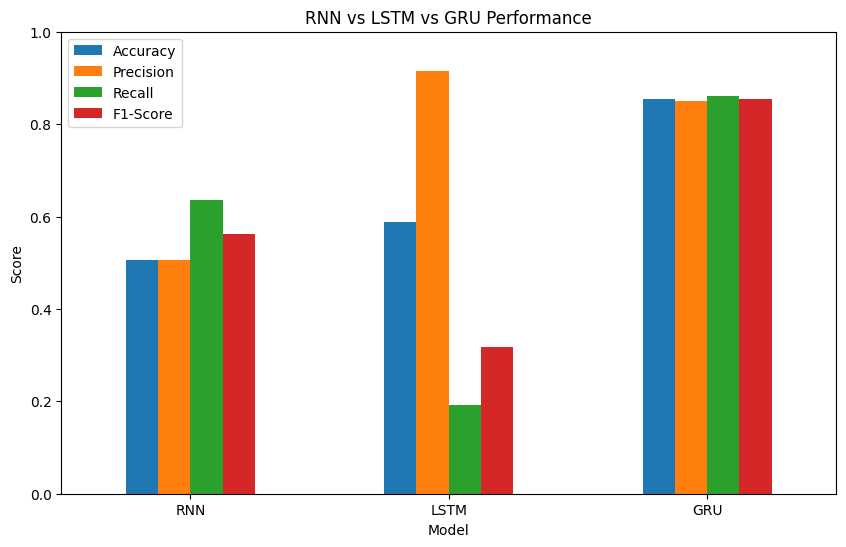

In [15]:
import matplotlib.pyplot as plt

results.set_index("Model")[[
    "Accuracy",
    "Precision",
    "Recall",
    "F1-Score"
]].plot(kind="bar", figsize=(10, 6))

plt.title("RNN vs LSTM vs GRU Performance")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.show()

## **17. Training time comparison**

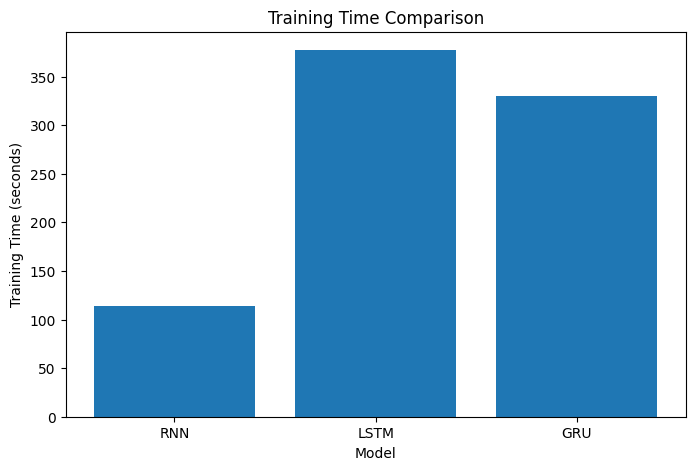

In [16]:
plt.figure(figsize=(8, 5))

plt.bar(
    results["Model"],
    results["Training Time (seconds)"]
)

plt.title("Training Time Comparison")
plt.xlabel("Model")
plt.ylabel("Training Time (seconds)")

plt.show()

## **Analysis of Results**

The three deep learning models, namely RNN, LSTM, and GRU, were implemented for binary sentiment classification using the IMDB movie review dataset.
The basic RNN provides a simple recurrent architecture for processing sequential text data. However, standard RNNs can have difficulty learning long-term dependencies because of issues such as vanishing gradients.
LSTM improves upon the basic RNN by using memory cells and gates to control the flow of information. This allows the model to retain useful information for longer sequences and generally improves sentiment classification performance.
GRU is another gated recurrent architecture. It has fewer gates and parameters than LSTM, making it computationally simpler while still being capable of learning long-term dependencies.
The final comparison should be based on the actual Accuracy, Precision, Recall, F1-score, and Training Time obtained from the experiment. The model with the highest F1-score can be considered the best-performing model for this experiment, while training time can be used to compare computational efficiency.

## **Conclusion**

In this assignment, RNN, LSTM, and GRU models were implemented for sentiment analysis using the IMDB movie review dataset. The text data was prepared through tokenization and padding before being given to the deep learning models.

The models were evaluated using Accuracy, Precision, Recall, F1-score, and Training Time. The results demonstrate the differences between a basic recurrent network and gated recurrent architectures.

The best-performing model should be selected based on the highest F1-score obtained in the experiment. LSTM and GRU are generally more effective than a basic RNN when learning long-term dependencies in sequential text, while GRU can provide a good balance between performance and computational complexity.